<a href="https://colab.research.google.com/github/JuanBona/Basketball-Analytics/blob/main/PracticandoDataAnaly.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub
import pandas as pd
import os
import matplotlib.pyplot as plt
# Esto descarga el dataset a una carpeta temporal de Colab
path = kagglehub.dataset_download("sumitrodatta/nba-aba-baa-stats")

print("Carpeta donde están los CSV:", path)

Using Colab cache for faster access to the 'nba-aba-baa-stats' dataset.
Carpeta donde están los CSV: /kaggle/input/nba-aba-baa-stats


In [ ]:
archivos = os.listdir(path)
print(archivos)

['Advanced.csv', 'Player Season Info.csv', 'Player Career Info.csv', 'Player Shooting.csv', 'Opponent Stats Per Game.csv', 'Draft Pick History.csv', 'Player Totals.csv', 'Opponent Stats Per 100 Poss.csv', 'Per 100 Poss.csv', 'Team Summaries.csv', 'Player Per Game.csv', 'All-Star Selections.csv', 'End of Season Teams (Voting).csv', 'Player Play By Play.csv', 'End of Season Teams.csv', 'Team Stats Per 100 Poss.csv', 'Per 36 Minutes.csv', 'Opponent Totals.csv', 'Team Abbrev.csv', 'Player Award Shares.csv', 'Team Totals.csv', 'Team Stats Per Game.csv']


In [ ]:
#leemos el csv e imprimos las primeras 5 columnas
csv_file= os.path.join(path, "Player Shooting.csv")
df = pd.read_csv(csv_file)
df.head(5)

,season,lg,player,player_id,age,team,pos,g,gs,mp,...,fg_percent_from_x16_3p_range,fg_percent_from_x3p_range,percent_assisted_x2p_fg,percent_assisted_x3p_fg,percent_dunks_of_fga,num_of_dunks,percent_corner_3s_of_3pa,corner_3_point_percent,num_heaves_attempted,num_heaves_made
0,2026,NBA,Precious Achiuwa,achiupr01,26,SAC,C,53,37,1123,...,0.000,0.328,0.571,1.000,0.119,34,0.410,0.280,0,0
1,2026,NBA,Steven Adams,adamsst01,32,HOU,C,32,11,730,...,NaN,NaN,0.514,NaN,0.129,13,NaN,NaN,0,0
2,2026,NBA,Bam Adebayo,adebaba01,28,MIA,C,53,53,1663,...,0.317,0.344,0.611,0.955,0.074,52,0.336,0.322,0,0
3,2026,NBA,Ochai Agbaji,agbajoc01,25,2TM,SG,49,13,760,...,0.500,0.267,0.794,0.957,0.124,20,0.465,0.250,0,0
4,2026,NBA,Ochai Agbaji,agbajoc01,25,TOR,SG,42,13,650,...,0.000,0.185,0.783,1.000,0.141,19,0.523,0.206,0,0


In [ ]:
# Obtenemos informacion sobre las columnas y nombres
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18193 entries, 0 to 18192
Data columns (total 32 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   season                         18193 non-null  int64  
 1   lg                             18193 non-null  object 
 2   player                         18193 non-null  object 
 3   player_id                      18193 non-null  object 
 4   age                            18193 non-null  int64  
 5   team                           18193 non-null  object 
 6   pos                            18192 non-null  object 
 7   g                              18193 non-null  int64  
 8   gs                             18193 non-null  int64  
 9   mp                             18193 non-null  int64  
 10  fg_percent                     18081 non-null  float64
 11  avg_dist_fga                   18081 non-null  float64
 12  percent_fga_from_x2p_range     18081 non-null 

In [ ]:
# Solo nos interesa quedarnos con la temporada 2024 y los que tienen mas de 10 tiros, entonces los seleccionamos de la siguiente manera
df_2024 = df.loc[df['season'] == 2024].copy()
df_2024 = df_2024.loc[df_2024['g'] >= 10]
df_2024.head()
#Reseteamos el índice para que arranque de 1
df_2024 = df_2024.reset_index(drop=True)
df_2024.index = df_2024.index + 1
# Buscamos el indice maximo, y luego buscamos la fila
maxporcentaje = df_2024['fg_percent'].idxmax()
mejor_tirador = df_2024.loc[maxporcentaje]
# Mostramos
print(f"El jugador con mejor porcentaje de tiro en 2024 es: {mejor_tirador['player']}")
print(f"Efectividad: {mejor_tirador['fg_percent'] * 100:.2f}%")
print(f"Partidos jugados: {mejor_tirador['g']}")


El jugador con mejor porcentaje de tiro en 2024 es: Daniel Gafford
Efectividad: 78.00%
Partidos jugados: 29


In [ ]:
# Ahora vamos a crear una nueva columna con la multiplicacion de minutos por partidos y partidos jugados
df_2024['total_min'] = df_2024['g'] * df_2024['mp']
df_2024.head()
top10 = df_2024.sort_values(by='total_min', ascending=False).head(10)

     season   lg            player  player_id  age team pos   g  gs    mp  \
488    2024  NBA  Domantas Sabonis  sabondo01   27  SAC   C  82  82  2928   
139    2024  NBA     DeMar DeRozan  derozde01   34  CHI  SF  79  79  2989   
81     2024  NBA     Mikal Bridges  bridgmi01   27  BRK  SF  82  82  2854   
587    2024  NBA        Coby White  whiteco01   23  CHI  PG  79  78  2881   
32     2024  NBA    Paolo Banchero  banchpa01   21  ORL  PF  80  80  2799   
227    2024  NBA         Josh Hart   hartjo01   28  NYK  SF  81  42  2707   
157    2024  NBA   Anthony Edwards  edwaran01   22  MIN  SG  79  78  2770   
396    2024  NBA   Dejounte Murray  murrade01   27  ATL  SG  78  78  2783   
280    2024  NBA      Nikola Jokić  jokicni01   28  DEN   C  79  79  2737   
464    2024  NBA     Austin Reaves  reaveau01   25  LAL  SG  82  57  2629   

     ...  fg_percent_from_x3p_range  percent_assisted_x2p_fg  \
488  ...                      0.379                    0.607   
139  ...                

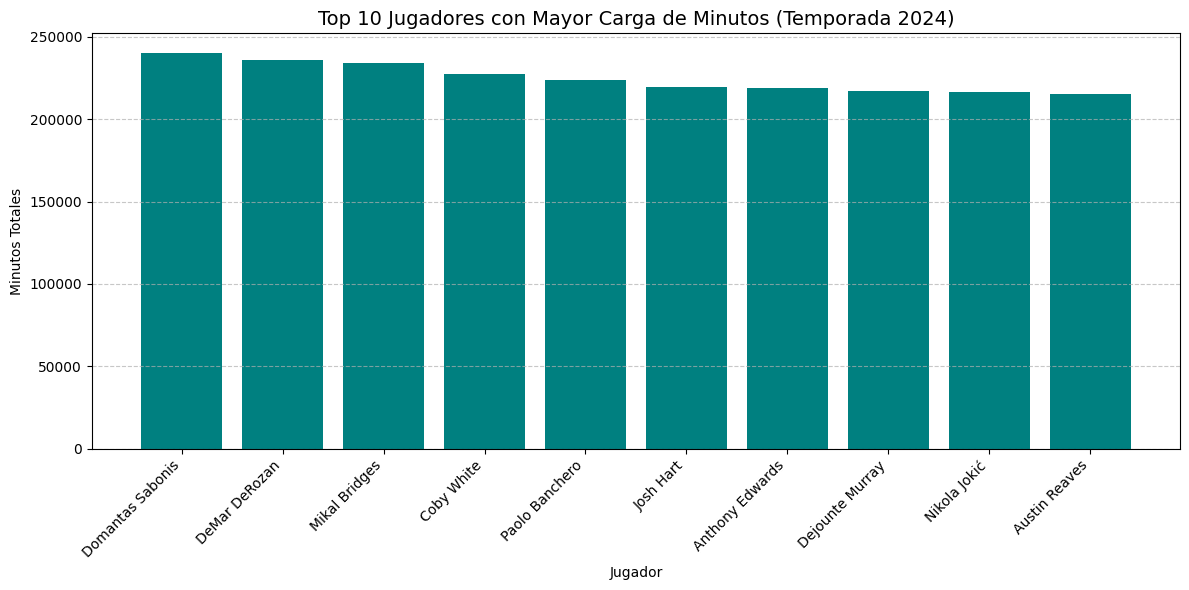

In [ ]:
plt.figure(figsize=(12, 6)) # Hacemos el gráfico más ancho
plt.bar(top10['player'], top10['total_min'], color='teal') # Un color más profesional

plt.xticks(rotation=45, ha='right') # 'ha' alinea el texto al final de la barra
plt.title("Top 10 Jugadores con Mayor Carga de Minutos (Temporada 2024)", fontsize=14)
plt.xlabel("Jugador")
plt.ylabel("Minutos Totales")
plt.grid(axis='y', linestyle='--', alpha=0.7) # Una grilla ayuda a leer los valores

plt.tight_layout() # Ajusta todo para que no se corten las etiquetas
plt.show()

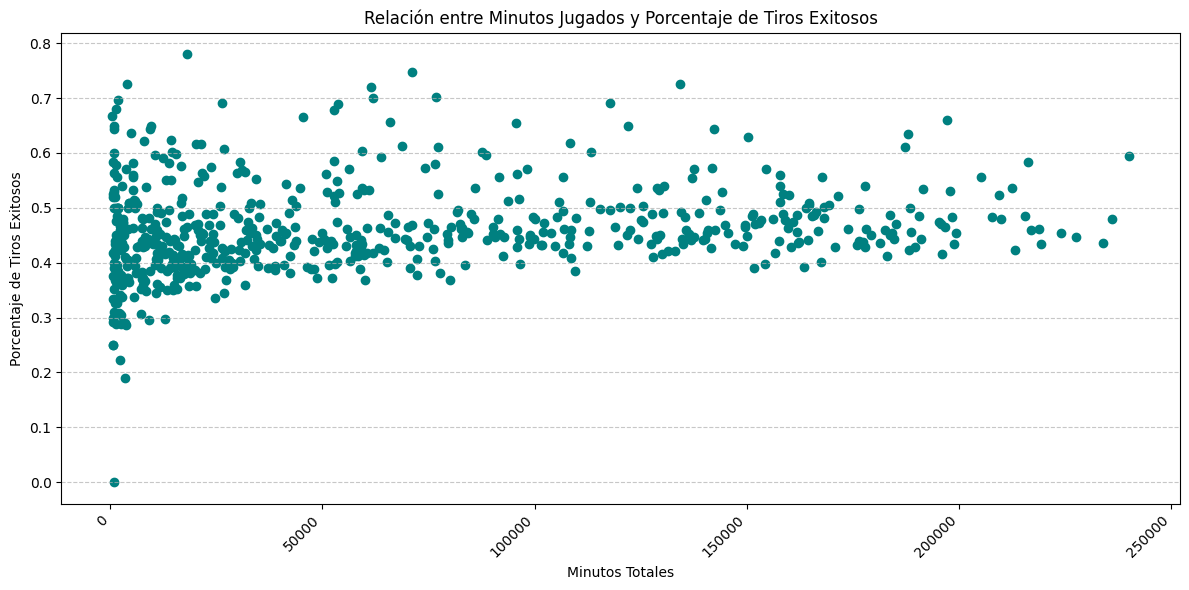

In [ ]:
# Ahora lo que queremos ver es si hay una correlacion entre el total de tiempo jugado y los puntos anotados por eso haremos un grafico de disperción
plt.figure(figsize=(12, 6))
plt.scatter(df_2024['total_min'],df_2024['fg_percent'], color='teal')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel("Minutos Totales")
plt.ylabel("Porcentaje de Tiros Exitosos")
plt.title("Relación entre Minutos Jugados y Porcentaje de Tiros Exitosos")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [ ]:
# Calculamos la correlación de Pearson
correlacion = df_2024['total_min'].corr(df_2024['fg_percent'])
print(f"El coeficiente de correlación de Pearson es: {correlacion:.2f}")

El coeficiente de correlación de Pearson es: 0.20


In [ ]:
# Abrimos el csv file y vemos sus primeras filas y columnas
csv_path_pg = os.path.join(path, "Player Totals.csv")
df_pg = pd.read_csv(csv_path_pg)
df_pg.head(5)

,season,lg,player,player_id,age,team,pos,g,gs,mp,...,orb,drb,trb,ast,stl,blk,tov,pf,pts,trp_dbl
0,2026,NBA,Precious Achiuwa,achiupr01,26.0,SAC,C,53,37.0,1123.0,...,111.0,197.0,308.0,65,49.0,30.0,39.0,89.0,428,0.0
1,2026,NBA,Steven Adams,adamsst01,32.0,HOU,C,32,11.0,730.0,...,145.0,131.0,276.0,48,22.0,20.0,35.0,55.0,187,0.0
2,2026,NBA,Bam Adebayo,adebaba01,28.0,MIA,C,53,53.0,1663.0,...,109.0,414.0,523.0,150,53.0,35.0,93.0,87.0,986,0.0
3,2026,NBA,Ochai Agbaji,agbajoc01,25.0,2TM,SG,49,13.0,760.0,...,38.0,74.0,112.0,40,18.0,14.0,22.0,79.0,221,0.0
4,2026,NBA,Ochai Agbaji,agbajoc01,25.0,TOR,SG,42,13.0,650.0,...,33.0,62.0,95.0,30,17.0,11.0,19.0,75.0,181,0.0


In [ ]:
#Selecionamos la temporada 2024
dfp2024 = df_pg.loc[df_pg['season'] == 2024].copy()
dfp2024.head(5)

,season,lg,player,player_id,age,team,pos,g,gs,mp,...,orb,drb,trb,ast,stl,blk,tov,pf,pts,trp_dbl
1407,2024,NBA,Precious Achiuwa,achiupr01,24.0,2TM,PF,74,18.0,1624.0,...,191.0,296.0,487.0,97,46.0,68.0,83.0,143.0,565,0.0
1408,2024,NBA,Precious Achiuwa,achiupr01,24.0,TOR,C,25,0.0,437.0,...,50.0,86.0,136.0,44,16.0,12.0,29.0,40.0,193,0.0
1409,2024,NBA,Precious Achiuwa,achiupr01,24.0,NYK,PF,49,18.0,1187.0,...,141.0,210.0,351.0,53,30.0,56.0,54.0,103.0,372,0.0
1410,2024,NBA,Bam Adebayo,adebaba01,26.0,MIA,C,71,71.0,2416.0,...,159.0,578.0,737.0,278,81.0,66.0,162.0,159.0,1367,2.0
1411,2024,NBA,Ochai Agbaji,agbajoc01,23.0,2TM,SG,78,28.0,1641.0,...,74.0,142.0,216.0,83,47.0,44.0,64.0,117.0,455,0.0


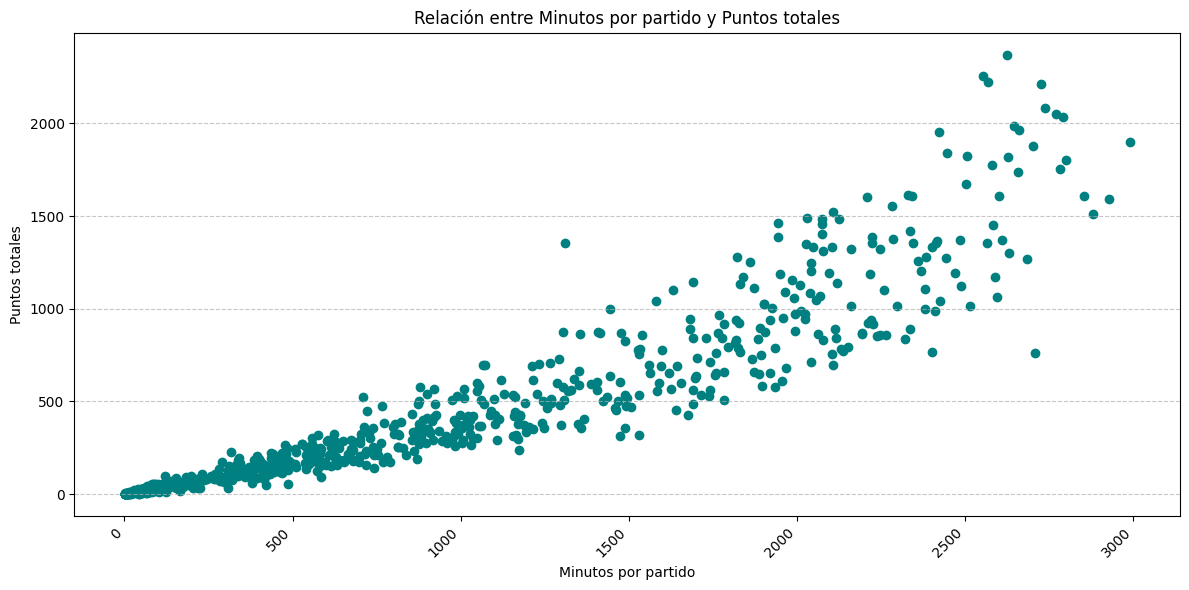

In [ ]:
# Vamos a utilizar el grafico de dispercion para observar si hay alguna coincidenicia
plt.figure(figsize=(12, 6))
plt.scatter(dfp2024['mp'],dfp2024['pts'], color='teal')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xlabel("Minutos por partido")
plt.ylabel("Puntos totales")
plt.title("Relación entre Minutos por partido y Puntos totales")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
correlacionpuntos = dfp2024['mp'].corr(dfp2024['pts'])
print(f"El coeficiente de correlación de Pearson es: {correlacionpuntos:.2f}")

El coeficiente de correlación de Pearson es: 0.93


In [ ]:
#Determinar qué posición en la cancha (Base, Escolta, Alero, etc.) tiene mayor capacidad anotadora y detectar si existen "outliers" (jugadores que anotan mucho más que el promedio de su propia posición).
pos2024 = [dfp2024['pos'].isin(['PG', 'SG', 'SF', 'PF', 'C'])]
Base2024 = dfp2024.loc[dfp2024['pos'] == 'PG']
PromedioBase2024 = Base2024['pts'].mean()
Escolta2024 = dfp2024.loc[dfp2024['pos'] == 'SG']
PromedioEscolta2024 = Escolta2024['pts'].mean()
Alero2024 = dfp2024.loc[dfp2024['pos'] == 'SF']
PromedioAlero2024 = Alero2024['pts'].mean()
AlaPivot2024 = dfp2024.loc[dfp2024['pos'] == 'PF']
PromedioAlaPivot2024 = AlaPivot2024['pts'].mean()
Pivot2024 = dfp2024.loc[dfp2024['pos'] == 'C']
PromedioPivot2024 = Pivot2024['pts'].mean()


In [ ]:
# Forma mas rapida aprendida
# 1. Filtramos para que solo queden las 5 posiciones puras
posiciones_interes = ['PG', 'SG', 'SF', 'PF', 'C']
df_filtrado = dfp2024[dfp2024['pos'].isin(posiciones_interes)].copy()

# 2. Calculamos el promedio de puntos por posición en UN SOLO PASO
promedios_por_pos = df_filtrado.groupby('pos')['pts'].mean()
# 3. Muestra
print("Promedio de puntos por posición:")
print(promedios_por_pos)

Promedio de puntos por posición:
pos
C     425.420168
PF    430.183007
PG    444.068493
SF    392.191083
SG    424.893750
Name: pts, dtype: float64


/tmp/ipykernel_12479/3590447232.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='pos', y='pts', data=df_filtrado, palette='viridis')


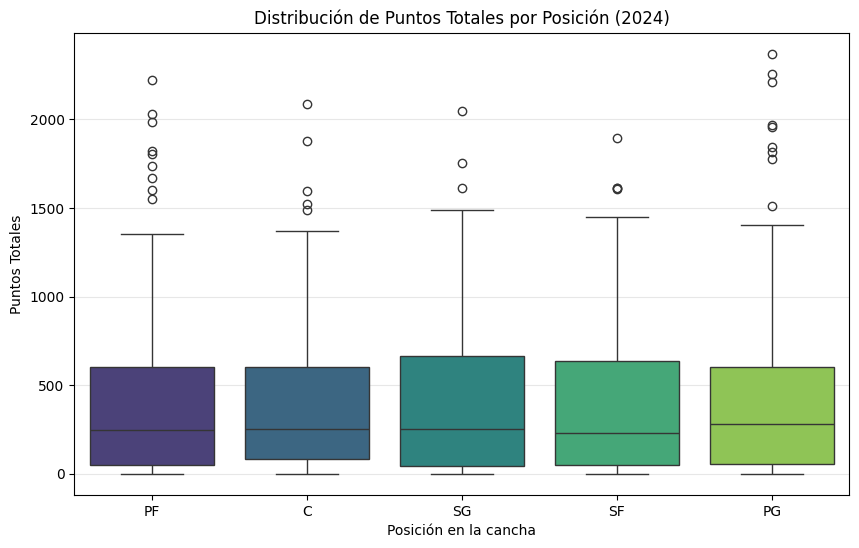

In [ ]:
import seaborn as sns

plt.figure(figsize=(10, 6))

# Creamos el boxplot
sns.boxplot(x='pos', y='pts', data=df_filtrado, palette='viridis')

plt.title('Distribución de Puntos Totales por Posición (2024)')
plt.xlabel('Posición en la cancha')
plt.ylabel('Puntos Totales')
plt.grid(axis='y', alpha=0.3)

plt.show()

In [ ]:
# Aprendiendo SkLearn
from sklearn.linear_model import LinearRegression
import numpy as np

# 1. Preparamos los datos
# Scikit-learn necesita que X sea una matriz (2D), por eso usamos .values.reshape(-1, 1)
X = df_filtrado['mp'].values.reshape(-1, 1)
y = df_filtrado['pts'].values

# 2. Creamos y entrenamos el modelo
modelo = LinearRegression()
modelo.fit(X, y)

# 3. ¡Hagamos una predicción!
# ¿Cuántos puntos metería un jugador si juega 2000 minutos en toda la temporada?
minutos_prueba = np.array([[2000]])
prediccion = modelo.predict(minutos_prueba)

print(f"Para 2000 minutos jugados, el modelo predice: {prediccion[0]:.2f} puntos.")

Para 2000 minutos jugados, el modelo predice: 1019.90 puntos.


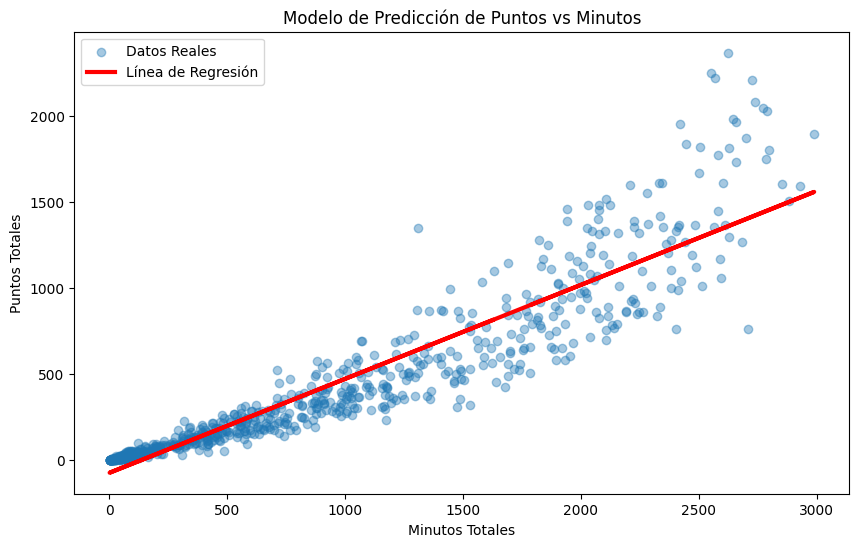

Precisión del modelo (R^2): 0.86
Cada minuto jugado equivale a 0.55 puntos.


In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, alpha=0.4, label='Datos Reales')
plt.plot(X, modelo.predict(X), color='red', linewidth=3, label='Línea de Regresión')

plt.title('Modelo de Predicción de Puntos vs Minutos')
plt.xlabel('Minutos Totales')
plt.ylabel('Puntos Totales')
plt.legend()
plt.show()

# Extra: El "Score" (R-cuadrado) nos dice qué tan bueno es el modelo (0 a 1)
print(f"Precisión del modelo (R^2): {modelo.score(X, y):.2f}")
print(f"Cada minuto jugado equivale a {modelo.coef_[0]:.2f} puntos.")

In [ ]:
df_filtrado['prediccion'] = modelo.predict(X)
df_filtrado['residuo'] = df_filtrado['pts'] - df_filtrado['prediccion']
top_eficientes = df_filtrado.sort_values(by='residuo', ascending=False).head(5)
print("🚀 Jugadores que rinden MUCHO MÁS de lo que sus minutos predicen:")
print(top_eficientes[['player', 'pts', 'prediccion', 'residuo']])

🚀 Jugadores que rinden MUCHO MÁS de lo que sus minutos predicen:
                       player   pts   prediccion      residuo
1578              Luka Dončić  2370  1360.969992  1009.030008
1642  Shai Gilgeous-Alexander  2254  1322.162690   931.837310
1421    Giannis Antetokounmpo  2222  1329.814834   892.185166
1516            Jalen Brunson  2212  1416.721327   795.278673
1593              Joel Embiid  1353   642.215038   710.784962


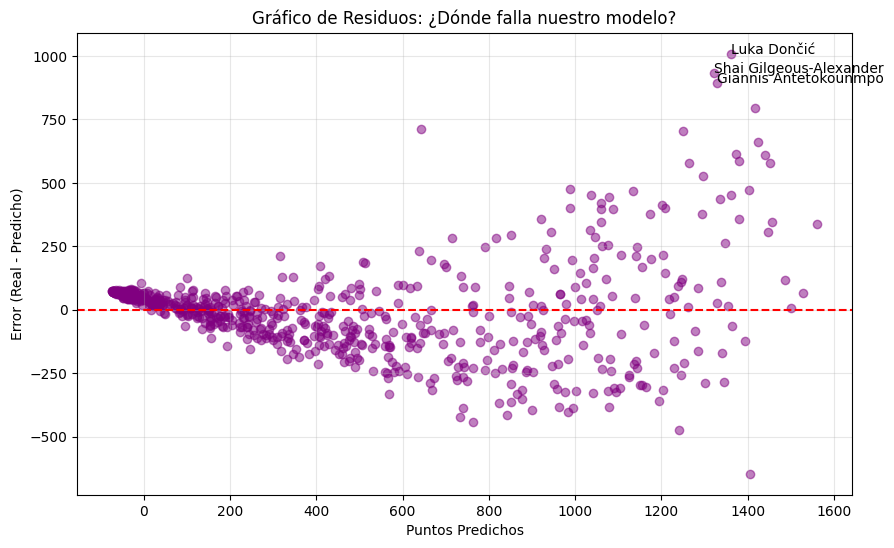

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df_filtrado['prediccion'], df_filtrado['residuo'], alpha=0.5, color='purple')
plt.axhline(y=0, color='red', linestyle='--') # Línea de "Error Cero"

plt.title('Gráfico de Residuos: ¿Dónde falla nuestro modelo?')
plt.xlabel('Puntos Predichos')
plt.ylabel('Error (Real - Predicho)')
plt.grid(True, alpha=0.3)

# Opcional: Etiquetar a los 3 más locos
for i, txt in enumerate(top_eficientes['player'].head(3)):
    plt.annotate(txt, (top_eficientes['prediccion'].iloc[i], top_eficientes['residuo'].iloc[i]))

plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
# Vamos a ver cuales son los mejores box to box de la NBA
features = ['pts','ast','trb','stl']
data_cluster = df_filtrado[features].fillna(0)
# Normalizamos ya que si un jugador anoto 1500 y 40 robos, el modelo solamente se guiara por los puntos anotados e ignorara el resto
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_cluster)
# Creamos 5 Klusters
kmeans = KMeans(n_clusters=5, random_state=42)
df_filtrado['cluster'] = kmeans.fit_predict(data_scaled)
print("¡Clusters creados! Ahora cada jugador tiene una etiqueta de grupo (0 al 4).")

¡Clusters creados! Ahora cada jugador tiene una etiqueta de grupo (0 al 4).


In [ ]:
resumen_clusters = df_filtrado.groupby('cluster')[features].mean()
print(resumen_clusters)

                 pts         ast         trb        stl
cluster                                                
0        1053.042553  174.638298  583.744681  55.446809
1          79.185915   18.690141   39.636620   6.771831
2        1707.805556  455.250000  428.916667  83.611111
3         419.668317   94.965347  186.623762  33.207921
4         915.536842  241.957895  257.294737  62.894737


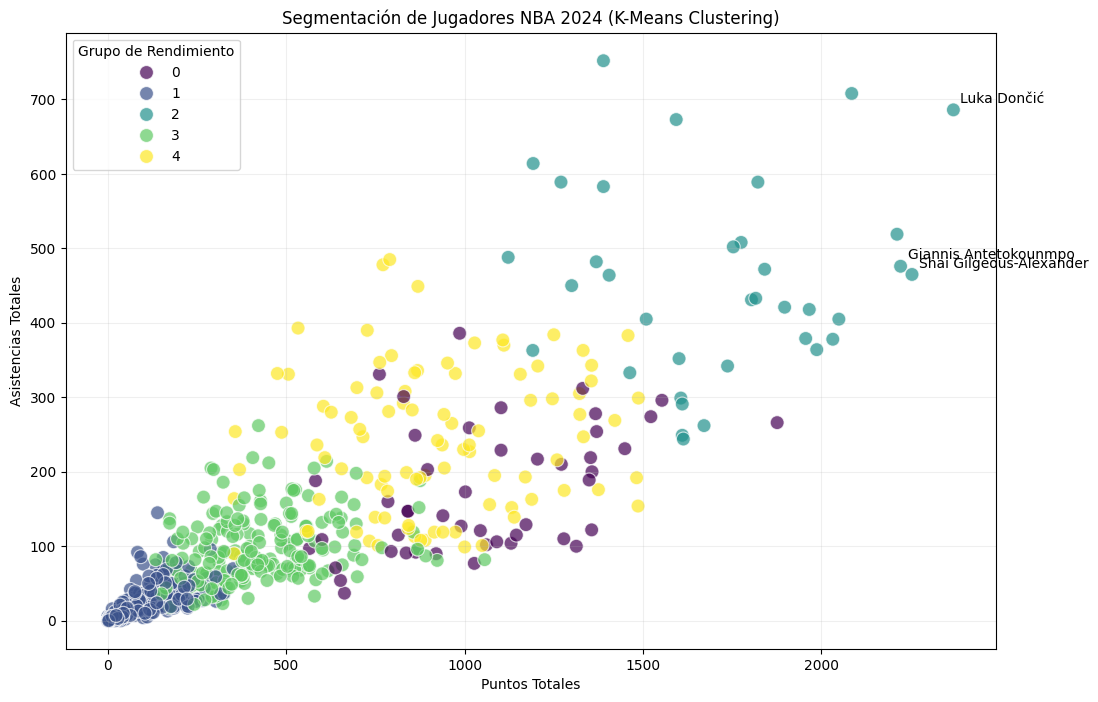

In [ ]:
plt.figure(figsize=(12, 8))

# Graficamos Puntos vs Asistencias usando el color del Cluster
sns.scatterplot(x='pts', y='ast', hue='cluster', data=df_filtrado,
                palette='viridis', s=100, alpha=0.7)

# Opcional: Marcar a las estrellas del Cluster 2 para que se entienda el gráfico
top_stars = df_filtrado[df_filtrado['cluster'] == 2].sort_values(by='pts', ascending=False).head(3)
for i, txt in enumerate(top_stars['player']):
    plt.annotate(txt, (top_stars['pts'].iloc[i], top_stars['ast'].iloc[i]),
                 xytext=(5,5), textcoords='offset points')

plt.title('Segmentación de Jugadores NBA 2024 (K-Means Clustering)')
plt.xlabel('Puntos Totales')
plt.ylabel('Asistencias Totales')
plt.legend(title='Grupo de Rendimiento')
plt.grid(True, alpha=0.2)
plt.show()

In [ ]:
## VibeCoding
# 1. Creamos un diccionario para mapear tus números de Cluster a nombres legibles
# (Basado en los promedios que me pasaste recién)
nombres_clusters = {
    2: 'Elite Superstars',
    0: 'Big Men / Rebounders',
    4: 'Solid Starters',
    3: 'Role Players',
    1: 'Bench / Low Minutes'
}

df_filtrado['perfil_ia'] = df_filtrado['cluster'].map(nombres_clusters)

# 2. BUSCANDO HÍBRIDOS:
# Caso A: Bases (PG) que la IA clasificó como "Big Men" (Reboteros)
bases_reboteros = df_filtrado[(df_filtrado['pos'] == 'PG') & (df_filtrado['cluster'] == 0)]

# Caso B: Pívots (C) que la IA clasificó como "Elite Superstars" o "Starters" (por sus asistencias/puntos)
pivots_modernos = df_filtrado[(df_filtrado['pos'] == 'C') & (df_filtrado['cluster'].isin([2, 4]))]

print("🏀 BASES CON ALMA DE PÍVOT (Muchos rebotes):")
print(bases_reboteros[['player', 'trb', 'pts', 'perfil_ia']])

print("\n🔥 PÍVOTS MODERNOS (Muchos puntos/asistencias):")
print(pivots_modernos[['player', 'ast', 'pts', 'perfil_ia']].sort_values(by='ast', ascending=False).head(10))

🏀 BASES CON ALMA DE PÍVOT (Muchos rebotes):
Empty DataFrame
Columns: [player, trb, pts, perfil_ia]
Index: []

🔥 PÍVOTS MODERNOS (Muchos puntos/asistencias):
                 player  ast   pts         perfil_ia
1747       Nikola Jokić  708  2085  Elite Superstars
1983   Domantas Sabonis  673  1593  Elite Superstars
1906       Kelly Olynyk  347   762    Solid Starters
1545       Zach Collins  194   776    Solid Starters
1727  Jaren Jackson Jr.  154  1486    Solid Starters
